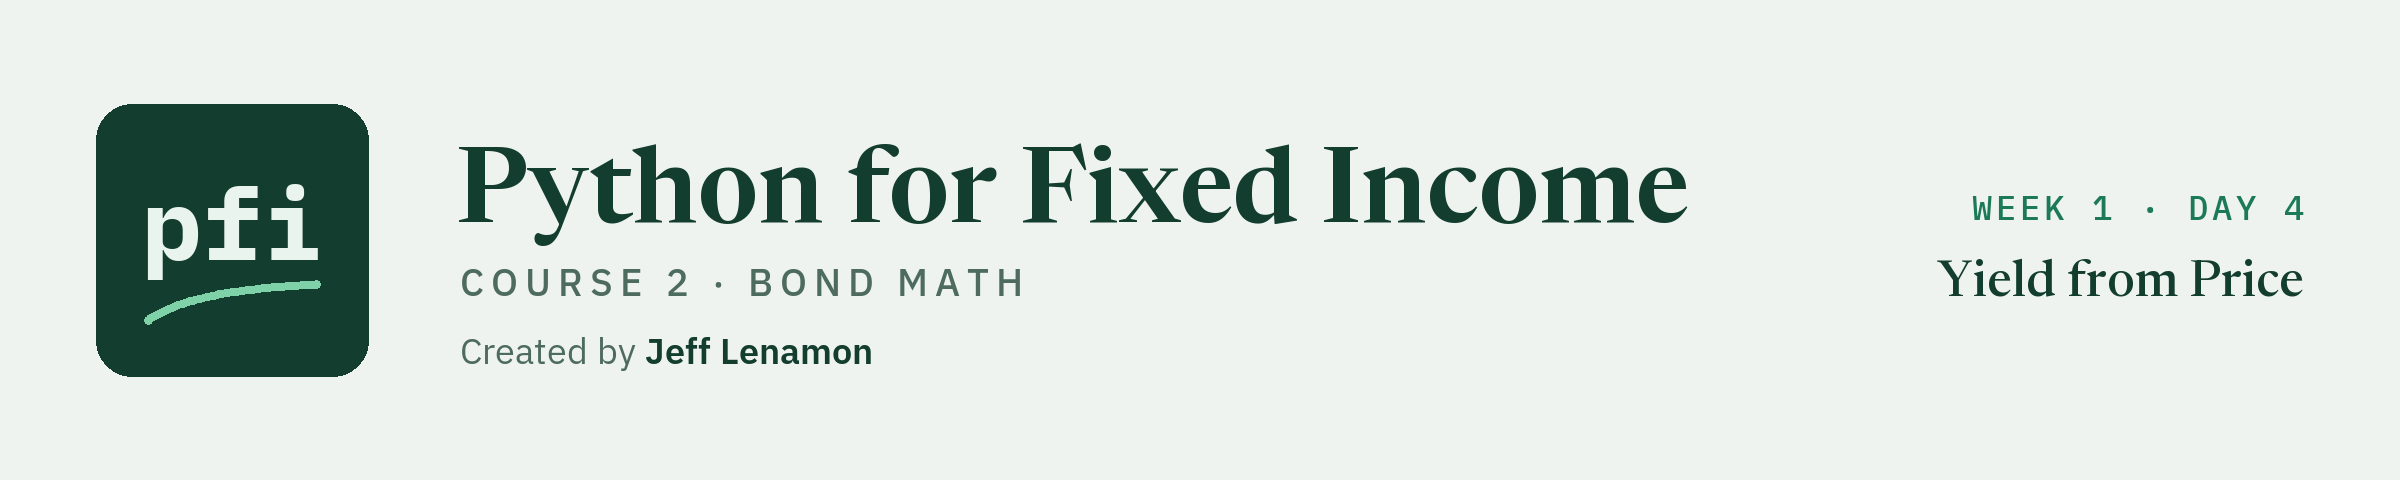

# Yield from Price

Week 1, Day 4. From a quoted price back to the yield: why there is no formula, how Excel's Goal Seek and RATE find it, and how a loop that halves a bracket finds it in your module, with a test that expects an error.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day4/04_yield_from_price.ipynb)

Yesterday ended with the arrow pointing one way: from a yield to a price. Give `price_from_yield` Quorvane Energy's 5.40 percent and it returns 99.3503. Day 3 showed how that price moves when the yield moves, and promised that today the arrow would turn around.

It has to, because **bonds are quoted on price.** A dealer's screen shows what you pay per 100 of face. The yield is what makes two quotes comparable: a price of 99.125 on a 5-year bond and 97.75 on a 10-year bond say nothing side by side until each is turned into a yield.

Suppose the desk's four new bonds are quoted on price on their coupon date, 30 September 2026: Quorvane Energy at 99.125, Dunmarrow Rail at 100.5, Pellwick Paper at 100.875, and Halvering Foods at 97.75. What yield does each price imply?

Today you will:

1. See why a price cannot be turned into a yield with a formula, and that a search can do it.
2. Find a yield with Excel's Goal Seek, and measure how close it gets.
3. Halve a bracket by hand, in a table, and build the same table in Excel.
4. Write a `while` loop that halves the bracket until it is narrower than you choose.
5. Add `yield_from_price` to your module, with a check that stops on a price no yield can explain.
6. Write a test that expects an error, with `pytest.raises`.
7. Go from price to yield and back to price, and undo a bad edit with `git restore`.

The bonds still settle on a coupon date, so `price_from_yield` from day 2 does every pricing step. Excel's `RATE` and `YIELD` are the answer key.

The issuers are invented, and so are the quotes. Every number here describes the data, and nothing says a bond or an issuer is good or bad.

The setup cell is the same as yesterday's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 3.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_04_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_04_osnvde24, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield']


* The two files exactly as day 3 left them: five functions and eight tests. By the end of today there will be six functions.

Record the starting point in Git first, as on days 2 and 3, so the Git section can show what today adds.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_04_osnvde24 and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 4: bondmath.py and test_bondmath.py as day 3 left them"
!git -C "{work}" log --oneline

5a16b78 Start of day 4: bondmath.py and test_bondmath.py as day 3 left them


* One commit, the start of day 4. Its hash changes on every run.

Q. Type in the four bonds with today's quoted prices.

In [8]:
bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30'],
    "years": [5, 7, 3, 10],
    # the quoted price, per 100 of face
    "quote": [99.125, 100.5, 100.875, 97.75],
})

bonds[["issuer", "coupon_pct", "years", "quote"]]

,issuer,coupon_pct,years,quote
0,Quorvane Energy,5.250,5,99.125
1,Dunmarrow Rail,6.125,7,100.500
2,Pellwick Paper,4.750,3,100.875
3,Halvering Foods,7.500,10,97.750


* No yield column. Finding it is today's job. Two quotes are above 100 and two below, so from day 3 you already know which two will yield less than their coupons: Dunmarrow and Pellwick.

## 4.1 Why Yield Has No Formula

Write Quorvane's price as day 2 did, with the yield left as a letter, y, in percent. Ten half-years, a coupon of 2.625 each time, and 100 more at the end:

price = 2.625 / (1 + y/100/2)^1 + 2.625 / (1 + y/100/2)^2 + ... + 2.625 / (1 + y/100/2)^9 + 102.625 / (1 + y/100/2)^10

Given y, the right-hand side is arithmetic: that is `price_from_yield`. Given the price, 99.125, the y sits inside ten terms, each raised to a different power. There is no general formula that rearranges this into `y = ...`, so a yield is found by **search**: guess a yield, price it, and adjust the guess.

One case needs no search. Day 3 showed that a bond whose coupon equals its yield prices at exactly 100, so a price of 100 means the yield is the coupon. None of today's quotes is 100.

Q. Guess some yields for Quorvane, price each one, and compare with the quote of 99.125.

In [9]:
quorvane = bonds.iloc[0]

for guess_pct in [5.0, 6.0, 5.5, 5.4, 5.45]:
    price = bondmath.price_from_yield(quorvane["coupon_pct"], guess_pct, quorvane["years"])
    # price falls as yield rises: a price above the quote means the guess is too low
    if price > quorvane["quote"]:
        verdict = "above the quote, so the yield is higher than this guess"
    else:
        verdict = "below the quote, so the yield is lower than this guess"
    print(f"{guess_pct:.2f} percent: price {price:.4f}, {verdict}")

5.00 percent: price 101.0940, above the quote, so the yield is higher than this guess
6.00 percent: price 96.8012, below the quote, so the yield is lower than this guess
5.50 percent: price 98.9200, below the quote, so the yield is lower than this guess
5.40 percent: price 99.3503, above the quote, so the yield is higher than this guess
5.45 percent: price 99.1349, above the quote, so the yield is higher than this guess


* 5.00 percent gives 101.0940, too high a price, so the yield is above 5.00. 6.00 percent gives 96.8012, too low, so the yield is below 6.00. After five guesses the yield is between 5.45 and 5.50.
* Every guess says which way to go, because price and yield move in opposite directions (day 3). **That one fact is all a search needs.** The rest of today is about making the guessing systematic.

## 4.2 Goal Seek in Excel

Excel has a tool that does the guessing for you: Goal Seek. You give it a cell with a formula, the value you want that formula to show, and the cell it may change. It changes that cell until the formula shows the value you asked for, or close to it.

Q. How do you find Quorvane's yield with Goal Seek?

**Excel walkthrough, tested in Excel.**

1. In a blank sheet, type `5` in A1. That is a first guess at the yield, in percent.
2. In B1, type `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,A1/100,100,2,0)`. It is day 2's `PRICE` with the yield read from A1, divided by 100.
3. Choose **Data**, **What-If Analysis**, **Goal Seek**. The dialog has three boxes:
   * **Set cell**: `B1`, the cell with the formula.
   * **To value**: `99.125`, the quote.
   * **By changing cell**: `A1`, the guess.
4. Click OK. Excel changes A1 until B1 shows a price close to 99.125.

When we ran exactly this in Excel, Goal Seek changed A1 to 5.452248461259856, and B1 then showed 99.12520671813279: 0.000207 above the quote.

Q. How close did Goal Seek get on each bond? The cell below types in what Excel's Goal Seek left in A1 and B1 for the four quotes, each started from 5 in A1, and compares the yield with Excel's `YIELD` from the reference file.

In [10]:
# what Goal Seek left in A1 (the yield) and B1 (the price), starting from 5 in A1, recorded from Excel
goal_seek = pd.DataFrame({
    "issuer": bonds["issuer"],
    "quote": bonds["quote"],
    "goal_seek_yield_pct": [5.452248461259856, 6.036363761470623, 4.435153807822778, 7.828571271933268],
    "goal_seek_price": [99.12520671813279, 100.50000082373151, 100.87535618968947, 97.75026237338443],
})

# Excel's YIELD for the same four quotes, from the reference file: a decimal, so times 100
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
yield_rows = tvm[tvm["function"] == "YIELD"].head(4)
goal_seek["excel_yield_pct"] = (yield_rows["excel_value"] * 100).to_numpy()

# how far the price is from the quote, and the yield from YIELD's, in basis points
goal_seek["price_gap"] = goal_seek["goal_seek_price"] - goal_seek["quote"]
goal_seek["yield_gap_bp"] = (goal_seek["goal_seek_yield_pct"] - goal_seek["excel_yield_pct"]) * 100
goal_seek[["issuer", "quote", "goal_seek_yield_pct", "excel_yield_pct", "price_gap", "yield_gap_bp"]]

,issuer,quote,goal_seek_yield_pct,excel_yield_pct,price_gap,yield_gap_bp
0,Quorvane Energy,99.125,5.452248,5.452297,2.067181e-04,-0.004804
1,Dunmarrow Rail,100.500,6.036364,6.036364,8.237315e-07,-0.000015
2,Pellwick Paper,100.875,4.435154,4.435281,3.561897e-04,-0.012744
3,Halvering Foods,97.750,7.828571,7.828610,2.623734e-04,-0.003889


* Goal Seek stopped close, not exactly on the quote: the price is up to 0.0004 away, and the yield up to 0.013 basis points from `YIELD`'s. For a quick answer in a sheet that is close.
* Where it stops depends on where it starts. Started from Quorvane's coupon, 5.25, instead of 5, the same Goal Seek stopped at 5.452293509043892, with B1 at 99.12501288383007.
* An answer key needs more than that: the same answer every time, and a search that stops only when the answer is as close as we say. That is what the next three sections build.

## 4.3 Bisection by Hand in a Table

Section 4.1 found that Quorvane's yield is between 5 and 6 percent. Call that the **bracket**. Now guess in a fixed way: always the middle of the bracket. Price the middle. If that price is above the quote, the yield is above the middle, so keep the upper half; otherwise keep the lower half. Each step halves the bracket. This is **bisection**.

Q. Halve Quorvane's bracket twelve times, and keep a row for every step.

In [11]:
# the bracket: the yield is between these two, in percent
low_pct, high_pct = 5.0, 6.0

rows = []
for step in range(1, 13):
    mid_pct = (low_pct + high_pct) / 2
    price_at_mid = bondmath.price_from_yield(quorvane["coupon_pct"], mid_pct, quorvane["years"])
    # a price above the quote means the yield is above the middle
    keep = "upper half" if price_at_mid > quorvane["quote"] else "lower half"
    rows.append({"step": step, "low_pct": low_pct, "high_pct": high_pct, "mid_pct": mid_pct,
                 "price_at_mid": price_at_mid, "keep": keep})
    # move one end of the bracket to the middle
    if price_at_mid > quorvane["quote"]:
        low_pct = mid_pct
    else:
        high_pct = mid_pct

halving = pd.DataFrame(rows)
# the bracket's width in basis points: 100 at the start, halved every step
halving["width_bp"] = (halving["high_pct"] - halving["low_pct"]) * 100
halving.round(6)

,step,low_pct,high_pct,mid_pct,price_at_mid,keep,width_bp
0,1,5.000000,6.000000,5.500000,98.919990,lower half,100.000000
1,2,5.000000,5.500000,5.250000,100.000000,upper half,50.000000
2,3,5.250000,5.500000,5.375000,99.458258,upper half,25.000000
3,4,5.375000,5.500000,5.437500,99.188691,upper half,12.500000
4,5,5.437500,5.500000,5.468750,99.054233,lower half,6.250000
5,6,5.437500,5.468750,5.453125,99.121435,lower half,3.125000
6,7,5.437500,5.453125,5.445312,99.155057,upper half,1.562500
7,8,5.445312,5.453125,5.449219,99.138244,upper half,0.781250
8,9,5.449219,5.453125,5.451172,99.129839,upper half,0.390625
9,10,5.451172,5.453125,5.452148,99.125637,upper half,0.195312


* Step 1 prices the middle, 5.50, at 98.9200: below the quote, so the yield is in the lower half, 5.00 to 5.50. Step 2 prices 5.25, the coupon, at 100.0000: above the quote, so the upper half, and so on.
* The width column halves every row: 100 basis points, 50, 25, and so on. After twelve steps the next bracket is 0.0244 basis points wide, and the twelfth middle is 5.452393.
* Ten steps cut the width by a factor of 1,024, about three more correct decimals. **Bisection always gets closer at the same pace**, and it cannot miss, because the yield is always inside the bracket.

**Excel side by side.** The same table in a sheet, tested in Excel. Type the headers `low_pct`, `high_pct`, `mid_pct`, and `price_at_mid` in A1:D1. Put the bracket, `5` and `6`, in A2 and B2. In C2 type `=(A2+B2)/2`, the middle, and in D2 `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,C2/100,100,2,0)`, the price at the middle. In row 3 the half to keep: A3 `=IF(D2>99.125,C2,A2)` and B3 `=IF(D2>99.125,B2,C2)`, then copy C2:D2 down to C3:D3. Select A3:D3 and fill down to row 13. C13 shows 5.452392578125, the twelfth middle above, exactly. Fill down to row 31 and C31 shows 5.452296503819525, against `YIELD`'s 5.4522965032957.

## 4.4 A `while` Loop That Halves the Bracket

The table took twelve steps because `range(1, 13)` said so. A better rule is to stop when the bracket is narrow enough, however many steps that takes. A `while` loop repeats for as long as its condition is true:

```python
while condition:
    ...   # runs again and again until the condition is false
```

The condition must become false at some point, or the loop never ends. Here the bracket halves every time round, so its width always falls below any limit you set.

Q. Halve Quorvane's bracket until it is narrower than 1e-10 percent, and count the steps.

In [12]:
low_pct, high_pct = 5.0, 6.0
steps = 0

# 1e-10 percent is a hundred-millionth of a basis point
while high_pct - low_pct > 1e-10:
    mid_pct = (low_pct + high_pct) / 2
    if bondmath.price_from_yield(quorvane["coupon_pct"], mid_pct, quorvane["years"]) > quorvane["quote"]:
        low_pct = mid_pct
    else:
        high_pct = mid_pct
    steps += 1

# the answer: the middle of the last bracket
quorvane_yield_pct = (low_pct + high_pct) / 2
print(f"Steps: {steps}. Quorvane at {quorvane['quote']} yields {quorvane_yield_pct:.8f} percent")

# Excel's RATE for the same quote, from the reference file (a decimal, so times 100)
excel_rate_pct = tvm.loc[tvm["case_id"] == "tvm_rate_11", "excel_value"].iloc[0] * 100
print(f"Excel's RATE:  {excel_rate_pct:.8f} percent, a gap of {abs(quorvane_yield_pct - excel_rate_pct) * 100:.1e} bp")

Steps: 34. Quorvane at 99.125 yields 5.45229650 percent
Excel's RATE:  5.45229650 percent, a gap of 2.0e-08 bp


* 34 steps, and the yield is 5.45229650 percent, the same as Excel's `RATE` to well within the course's tolerance of 1e-6 percent.
* `steps += 1` adds 1 to `steps`, a short way to write `steps = steps + 1`.

Q. A bracket of 5 to 6 percent suited Quorvane. How many steps from -5 to 100 percent, a bracket wide enough for any bond in the course?

In [13]:
low_pct, high_pct = -5.0, 100.0
steps = 0
while high_pct - low_pct > 1e-10:
    mid_pct = (low_pct + high_pct) / 2
    if bondmath.price_from_yield(quorvane["coupon_pct"], mid_pct, quorvane["years"]) > quorvane["quote"]:
        low_pct = mid_pct
    else:
        high_pct = mid_pct
    steps += 1

print(f"Steps: {steps}. Yield: {(low_pct + high_pct) / 2:.8f} percent")

Steps: 40. Yield: 5.45229650 percent


* 40 steps instead of 34, and the same yield. A bracket 105 times wider needs only about seven more halvings, because 2 to the power 7 is 128. So the module can start wide and never needs a good first guess.

## 4.5 `yield_from_price` with a Check That Stops

The loop goes into the module as a function. One thing comes first: the yield must be inside the bracket. If it is not, bisection still runs and returns the end of the bracket it was squeezed against, a wrong number with no warning.

Q. What prices can a yield between -5 and 100 percent produce for Quorvane?

In [14]:
# the lowest yield gives the highest price, and the highest yield the lowest price
highest_price = bondmath.price_from_yield(quorvane["coupon_pct"], -5.0, quorvane["years"])
lowest_price = bondmath.price_from_yield(quorvane["coupon_pct"], 100.0, quorvane["years"])

print(f"At -5 percent:  {highest_price:.4f}")
print(f"At 100 percent: {lowest_price:.4f}")

At -5 percent:  159.0631
At 100 percent: 6.8931


* Any price from 6.8931 to 159.0631 has a yield inside the bracket. A price outside that range, such as 1,000 from a typing slip, has none, and the function must say so instead of answering.

Q. Add `yield_from_price` to the end of `bondmath.py`. Read the cell before you run it.

In [15]:
%%writefile -a bondmath.py


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring states the units, percent and per 100 in and percent out, the convention, the bracket and when the search stops, the `ValueError`, and the Excel route.
* The check first: price the two ends of the bracket, and raise `ValueError` if the price is not between them. `lowest_price <= price <= highest_price` is a chained comparison, true only when both parts are true.
* Then section 4.4's loop, with the comments that say which half is kept and why.

Q. Reload the module, find the yield of each quote, and put Excel's `RATE` and `YIELD` beside it.

In [16]:
# the file changed, so read it again
importlib.reload(bondmath)

bonds["yield_pct"] = [
    bondmath.yield_from_price(c, p, t) for c, p, t in zip(bonds["coupon_pct"], bonds["quote"], bonds["years"])
]

# Excel's answers for the same four quotes, both decimals in the file, so times 100
rate_rows = tvm[tvm["case_id"].isin(["tvm_rate_11", "tvm_rate_12", "tvm_rate_13", "tvm_rate_14"])]
bonds["excel_rate_pct"] = (rate_rows["excel_value"] * 100).to_numpy()
bonds["excel_yield_pct"] = (yield_rows["excel_value"] * 100).to_numpy()

# the module must agree with both Excel routes within the course's tolerance
assert (bonds["yield_pct"] - bonds["excel_rate_pct"]).abs().max() < 1e-6
assert (bonds["yield_pct"] - bonds["excel_yield_pct"]).abs().max() < 1e-6
bonds[["issuer", "coupon_pct", "quote", "yield_pct", "excel_rate_pct", "excel_yield_pct"]].round(6)

,issuer,coupon_pct,quote,yield_pct,excel_rate_pct,excel_yield_pct
0,Quorvane Energy,5.250,99.125,5.452297,5.452297,5.452297
1,Dunmarrow Rail,6.125,100.500,6.036364,6.036364,6.036364
2,Pellwick Paper,4.750,100.875,4.435281,4.435281,4.435281
3,Halvering Foods,7.500,97.750,7.828610,7.828610,7.828610


* Quorvane at 99.125 yields 5.4523 percent, Dunmarrow at 100.50 6.0364, Pellwick at 100.875 4.4353, and Halvering at 97.75 7.8286.
* The two quotes above 100 yield less than their coupons, and the two below 100 yield more: day 3's rule, read from the other side.
* Excel's two routes and the module agree. `RATE` and `YIELD` themselves differ by at most 6e-09 percent on the eight quotes in the file, far inside the tolerance.

**Excel side by side.** Two Excel routes, both tested in Excel. `RATE` solves for the rate per period of an annuity: `=RATE(2*5,5.25/2,-99.125,100)*2`. The arguments are the number of periods, the coupon per period, the price you pay with a minus sign (money out, the sign convention `PV` showed on day 1), and the 100 you get back at the end. `RATE` returns the rate per half-year, so `*2` makes it annual. Excel returns 0.05452296503527843, a decimal: times 100 it is 5.452297 percent. `YIELD` takes the dates: `=YIELD(DATE(2026,9,30),DATE(2031,9,30),5.25/100,99.125,100,2,0)` returns 0.054522965032957. The coupon goes in as a decimal, the price per 100 as it is quoted, and the yield comes back as a decimal.

Q. What happens if the price is 1,000?

In [17]:
# try and except, as on day 2: catch the error and print its message
try:
    bondmath.yield_from_price(5.25, 1000.0, 5)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: price 1000.0 is outside 6.893110 to 159.063092, the prices at yields of 100.0 and -5.0 percent


* The function refuses, and the message gives the range it can explain. Without the check the loop would have squeezed the bracket against -5 percent and returned that: a yield that looks like a number and means nothing. The Git section shows exactly that.

Q. Add the first test: `yield_from_price` against every `RATE` row in the week 1 file, and Excel's `YIELD` on every bond-file row that settles on a coupon date.

In [18]:
%%writefile -a test_bondmath.py


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* The first loop covers 18 `RATE` rows, today's eight quotes among them. `RATE` times the frequency is the annual yield as a decimal, so the expected value is Excel's times 100.
* The second loop reuses day 2's filter: rows with no days accrued (`coupdaybs` is 0), where the years left are `coupnum` over the frequency. `yield_pct_from_price` is Excel's `YIELD` of that row's price, already times 100 in the file.

## 4.6 `pytest.raises`

The check that stops needs a test too: a test that passes only if the function raises the error. Day 2 wrote one with `try` and `except`:

```python
try:
    bondmath.cash_flows(6.0, 2.3, 2)
except ValueError:
    return
assert False, "cash_flows accepted 2.3 years at frequency 2"
```

It works, but it takes four lines to say one thing. pytest has its own way, a `with` block:

```python
with pytest.raises(ValueError):
    bondmath.yield_from_price(6.0, 1000.0, 5, 2)
```

The block passes only if the code inside raises a `ValueError`. If the code returns normally, `pytest.raises` fails the test with `DID NOT RAISE`. You will see that message in the Git section.

Q. Try `pytest.raises` in a cell first, and print the message of the error it caught.

In [19]:
# the with block passes only if the code inside raises ValueError; "as caught" keeps the error
with pytest.raises(ValueError) as caught:
    bondmath.yield_from_price(5.25, 1000.0, 5)

print(f"pytest.raises caught a ValueError: {caught.value}")

pytest.raises caught a ValueError: price 1000.0 is outside 6.893110 to 159.063092, the prices at yields of 100.0 and -5.0 percent


* No error stopped the cell: `pytest.raises` caught it, as it was told to. `caught.value` is the error itself, with the message from section 4.5.

Q. Add the test. It checks a price too high for any yield in the bracket, and one too low.

In [20]:
%%writefile -a test_bondmath.py


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)

Appending to test_bondmath.py


* Two `with` blocks, one for each end. A price of 0.01 for a 6 percent 5-year bond would need a yield far above 100 percent.

## 4.7 Price to Yield to Price, Round Trip

Two functions that undo each other can check each other. Price a bond from a yield, solve the yield back from that price, and the yield you get should be the one you started with.

Q. Price each bond at the yield it was issued at (day 2), then solve the yield back.

In [21]:
# the yields from days 2 and 3, in the same order as the bonds
issue_yields_pct = [5.40, 6.125, 4.60, 7.70]

rows = []
for bond, issue_yield_pct in zip(bonds.itertuples(), issue_yields_pct):
    price = bondmath.price_from_yield(bond.coupon_pct, issue_yield_pct, bond.years)
    yield_back_pct = bondmath.yield_from_price(bond.coupon_pct, price, bond.years)
    rows.append({"issuer": bond.issuer, "issue_yield_pct": issue_yield_pct, "price": price,
                 "yield_back_pct": yield_back_pct, "gap_bp": (yield_back_pct - issue_yield_pct) * 100})

trip = pd.DataFrame(rows)
assert trip["gap_bp"].abs().max() < 1e-6
trip

,issuer,issue_yield_pct,price,yield_back_pct,gap_bp
0,Quorvane Energy,5.400,99.350327,5.400,1.100453e-09
1,Dunmarrow Rail,6.125,100.000000,6.125,-1.864464e-09
2,Pellwick Paper,4.600,100.415887,4.600,-1.555200e-09
3,Halvering Foods,7.700,98.622736,7.700,1.573408e-09


* Each yield comes back within 2e-09 basis points, inside the search's final bracket of 1e-8 basis points.

Q. And the other way: from each quote to its yield, and back to a price.

In [22]:
bonds["price_back"] = [
    bondmath.price_from_yield(c, y, t) for c, y, t in zip(bonds["coupon_pct"], bonds["yield_pct"], bonds["years"])
]
bonds["gap"] = bonds["price_back"] - bonds["quote"]

assert bonds["gap"].abs().max() < 1e-8
bonds[["issuer", "quote", "yield_pct", "price_back", "gap"]]

,issuer,quote,yield_pct,price_back,gap
0,Quorvane Energy,99.125,5.452297,99.125,1.389822e-11
1,Dunmarrow Rail,100.500,6.036364,100.500,2.452083e-10
2,Pellwick Paper,100.875,4.435281,100.875,5.219647e-11
3,Halvering Foods,97.750,7.828610,97.750,-1.202238e-10


* Every quote comes back to within 2e-10 per 100 of face. Compare Goal Seek in section 4.2, whose price stopped up to 0.0004 from the quote.

Q. Add the round-trip test.

In [23]:
%%writefile -a test_bondmath.py


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)

Appending to test_bondmath.py


* A 5.25 percent 7-year bond priced at 6.1 percent must solve back to 6.1 within 1e-8 percent. A round trip checks that the two functions undo each other; the test against Excel's rows checks that they are right.

Q. Run the tests.

In [24]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........                                                              [100%]
11 passed in 0.04s



* 11 dots and `11 passed`: the eight from days 1 to 3, and today's three.

## Excel Side by Side

Today's Excel, in one place. Every formula and every step was tested in Excel.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Guess and adjust | the guesses in 4.1 | 5 in A1, `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,A1/100,100,2,0)` in B1; Data, What-If Analysis, Goal Seek: Set cell B1, To value 99.125, By changing cell A1 | A1 5.452248, B1 99.125207 |
| Bisection by hand | the table in 4.3 | 5 and 6 in A2:B2, `=(A2+B2)/2` in C2, `=PRICE(...,C2/100,100,2,0)` in D2, `=IF(D2>99.125,C2,A2)` in A3, `=IF(D2>99.125,B2,C2)` in B3, filled down | C13 5.452393, C31 5.452297 |
| Yield from price, annuity route | `bondmath.yield_from_price(5.25, 99.125, 5)` | `=RATE(2*5,5.25/2,-99.125,100)*2` | 0.05452296503527843 |
| Yield from price, bond route | the same | `=YIELD(DATE(2026,9,30),DATE(2031,9,30),5.25/100,99.125,100,2,0)` | 0.054522965032957 |
| In percent | the same | `=RATE(2*5,5.25/2,-99.125,100)*2*100` | 5.452297 |

`RATE(nper, pmt, pv, fv)` returns the rate per period, so the formula multiplies by 2 for an annual yield, then by 100 for percent. The price goes in with a minus sign, because it is money paid. `YIELD` takes the coupon as a decimal and the price per 100, and returns a decimal.

To try it: in a blank sheet, type the Goal Seek example and run it, then type the `RATE` formula in another cell and compare. Then build the bisection table and fill it down until C stops changing in the decimals you can see.

Q. Does `bondmath` agree with Excel on every `RATE` and `YIELD` row, and on every coupon-date row of the bond file?

In [25]:
rows = []
for row in tvm[tvm["function"].isin(["RATE", "YIELD"])].itertuples():
    # RATE and YIELD rows both hold the annual yield as a decimal
    python_value = bondmath.yield_from_price(row.coupon_pct, row.price, row.years, int(row.frequency))
    rows.append({"case_id": row.case_id, "excel": row.excel_value * 100, "python": python_value})

reference = pd.read_csv("bondmath_excel_reference.csv")
for row in reference[reference["coupdaybs"] == 0].itertuples():
    # on a coupon date the years left are the coupons left over the frequency
    python_value = bondmath.yield_from_price(row.coupon_pct, row.price, row.coupnum / row.frequency, int(row.frequency))
    rows.append({"case_id": row.case_id, "excel": row.yield_pct_from_price, "python": python_value})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel"]).abs()
assert answer_key["gap"].max() < 1e-6, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e} percent")

# today's four quotes, by YIELD
answer_key[answer_key["case_id"].isin(["tvm_yield_01", "tvm_yield_02", "tvm_yield_03", "tvm_yield_04"])]

Rows compared: 43, largest gap: 6.2e-09 percent


,case_id,excel,python,gap
18,tvm_yield_01,5.452297,5.452297,3.226752e-12
19,tvm_yield_02,6.036364,6.036364,4.331913e-11
20,tvm_yield_03,4.435281,4.435281,2.824925e-09
21,tvm_yield_04,7.828610,7.828610,1.924239e-11


* All 43 rows agree: 18 `RATE` rows, 8 `YIELD` rows, and 17 coupon-date rows of the bond file, at frequencies 1, 2, and 4. The largest gap is 6.2e-09 percent.

## Save the Day with Git

First, commit today's work, as every day. Then today's Git step: **the undo button.** A commit is a saved copy you can return to. If an edit breaks a file before you commit it, one command puts the file back exactly as it was in the last commit.

Q. What has changed since the start of the day?

In [26]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 29 +++++++++++++++++++++++++++++
 test_bondmath.py | 30 ++++++++++++++++++++++++++++++
 2 files changed, 59 insertions(+)


* ` M` beside both files: 29 lines added to `bondmath.py` and 30 to `test_bondmath.py`. The `??` lines are files Git is not tracking: the two reference files and `__pycache__`, the folder where Python keeps compiled copies of the module. Day 6 tells Git to ignore that folder.

Q. Commit with a subject that says what and a body that says why.

In [27]:
# two -m options: the subject, then the body
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add yield_from_price, tested against Excel RATE and YIELD" -m "Bonds are quoted on price, and the yield is what makes two quotes comparable."
!git -C "{work}" log --oneline

7ddd37a Add yield_from_price, tested against Excel RATE and YIELD


5a16b78 Start of day 4: bondmath.py and test_bondmath.py as day 3 left them


* Two commits: the start of day 4, and today's work on top.

Now the undo button. Suppose an edit tidies `yield_from_price` and deletes the bracket check, on the theory that no real bond yields below -5 or above 100 percent. The edit might be yours, or an assistant's. It runs without an error.

Q. Make the bad edit: delete the check from `bondmath.py`.

In [28]:
# a bad edit, for the lesson: cut out every line from the first bracket price to the comment before the loop
text = Path("bondmath.py").read_text(encoding="utf-8")
start = text.index("    highest_price = price_from_yield(")
end = text.index("    # halve the bracket until it is narrow enough")
Path("bondmath.py").write_text(text[:start] + text[end:], encoding="utf-8")

importlib.reload(bondmath)
print(f"A price of 1,000 now returns a yield of {bondmath.yield_from_price(5.25, 1000.0, 5):.4f} percent")

A price of 1,000 now returns a yield of -5.0000 percent


* No error. The function now answers a price of 1,000 with -5.0000 percent, the bottom of the bracket: exactly the silent wrong number section 4.5 warned about.

Q. Do the tests notice?

In [29]:
# run the tests on the edited file
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.........F.                                                              [100%]
================================== FAILURES ===================================
______________________ test_yield_raises_outside_bracket ______________________

    def test_yield_raises_outside_bracket():
        # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
>       with pytest.raises(ValueError):
             ^^^^^^^^^^^^^^^^^^^^^^^^^
E       Failed: DID NOT RAISE ValueError

test_bondmath.py:134: Failed
=========================== short test summary info ===========================
FAILED test_bondmath.py::test_yield_raises_outside_bracket - Failed: DID NOT RAISE ValueError
1 failed, 10 passed in 0.05s



* `1 failed`. The failing test is `test_yield_raises_outside_bracket`, with `Failed: DID NOT RAISE`: the call returned instead of raising, so `pytest.raises` failed the test, as section 4.6 said it would. The test you wrote today caught the edit.

Q. What exactly did the edit change?

In [30]:
# every line that differs from the last commit: - removed, + added
!git -C "{work}" diff bondmath.py

diff --git a/bondmath.py b/bondmath.py
index 36723a6..02e4c11 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -126,11 +126,6 @@ def yield_from_price(coupon_pct: float, price: float, years: float, frequency: i
     """
     # the bracket: price falls as yield rises, so the low yield gives the high price
     low_pct, high_pct = -5.0, 100.0
-    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
-    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
-    if not lowest_price <= price <= highest_price:
-        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
-                         f"the prices at yields of {high_pct} and {low_pct} percent")
     # halve the bracket until it is narrow enough
     while high_pct - low_pct > 1e-10:
         mid_pct = (low_pct + high_pct) / 2


* 5 lines with a `-` in front, removed, and none added. The diff is how you check what an edit did before you decide whether to keep it.

Q. Undo it: put `bondmath.py` back exactly as it was in the last commit.

In [31]:
# restore replaces the file with its copy in the last commit; status then shows no M beside it
!git -C "{work}" restore bondmath.py
!git -C "{work}" status --short

?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* No ` M` beside `bondmath.py`: the file is the committed version again. Only the untracked `??` lines remain.
* `git restore` throws the uncommitted change away for good. That is what you want for a bad edit, so read the diff first.

Q. Run the tests again.

In [32]:
# run the tests on the restored file
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........                                                              [100%]
11 passed in 0.02s



* `11 passed`. One command undid the edit, and the tests confirm it.

In [33]:
# the module in memory still has the edit: reload it from the restored file
importlib.reload(bondmath)

try:
    bondmath.yield_from_price(5.25, 1000.0, 5)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: price 1000.0 is outside 6.893110 to 159.063092, the prices at yields of 100.0 and -5.0 percent


* The check is back: a price of 1,000 is refused again.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the `%%writefile -a bondmath.py` cell in section 4.5, without its first line. In `test_bondmath.py`, do the same with the three `%%writefile -a test_bondmath.py` cells, in order. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
...........                                                              [100%]
11 passed in 0.08s
```

If you added the exercise functions of days 1 to 3 with their tests, you will see 14 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add yield_from_price, tested against Excel RATE and YIELD" -m "Bonds are quoted on price, and the yield is what makes two quotes comparable."
git log --oneline
```

**Step 5.** Keep the undo button in mind. If an edit to `bondmath.py` goes wrong before you commit it, these three lines show what changed and put the file back as it was in your last commit:

```powershell
git status --short
git diff bondmath.py
git restore bondmath.py
```

`git restore` discards the uncommitted change for good, so read the diff first.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* Say why a yield has no formula, and that price falling as yield rises is all a search needs.
* Find a yield with Excel's Goal Seek, and say how close it gets.
* Halve a bracket by hand in Python and in a sheet, and say why bisection cannot miss.
* Write a `while` loop that stops when the bracket is narrow enough.
* Solve a yield from a price with `yield_from_price`, and with Excel's `RATE` and `YIELD`.
* Write a test that expects an error with `pytest.raises`, and check two functions against each other with a round trip.
* Undo a bad edit with `git diff` and `git restore`.

Tomorrow, day 5, closes the week with a case study: a desk's calendar of eight invented new issues. You will turn re-offer prices into yields, price the calendar at a common yield, find the coupon that prices nearest par, and write the calendar to a workbook of Excel formulas to open in Excel.

## Exercises

The exercises use the second set of four bonds from days 1 to 3, now quoted on price on 30 September 2026 like the first four. The issuers and the quotes are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds with their quotes and defines `check`, a small function that marks your answers.

In [34]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    # the quoted price, per 100 of face
    "quote": [99.5, 100.25, 98.375, 97.625],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,quote
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,99.500
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,100.250
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,98.375
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,97.625


### Exercise 1

Q. With `bondmath.yield_from_price`, find the yield of each exercise bond from its quote. Store Osmere's yield, in percent and unrounded, in **ex1_osmere**, and the ticker of the bond with the highest yield in **ex1_highest**.

In [35]:
ex1_osmere = ...
ex1_highest = ...

In [36]:
check("Exercise 1 Osmere yield", ex1_osmere, 5.319909556762923)
check("Exercise 1 highest yield", ex1_highest, "CLDB")

Exercise 1 Osmere yield: not attempted yet
Exercise 1 highest yield: not attempted yet


### Exercise 2

Q. Suppose Halvering's quote rises one point, from 97.75 to 98.75, and Pellwick's rises one point, from 100.875 to 101.875. By how many basis points does each yield change? Store the two changes, unrounded and negative for a fall, in **ex2_halvering_bp** and **ex2_pellwick_bp**, and in **ex2_larger** the ticker whose yield moves more, `"HLVF"` or `"PLWK"`. The quotes are what-ifs.

In [37]:
ex2_halvering_bp = ...
ex2_pellwick_bp = ...
ex2_larger = ...

In [38]:
check("Exercise 2 Halvering change", ex2_halvering_bp, -14.724150213623943)
check("Exercise 2 Pellwick change", ex2_pellwick_bp, -35.56528486387833)
check("Exercise 2 larger move", ex2_larger, "PLWK")

Exercise 2 Halvering change: not attempted yet
Exercise 2 Pellwick change: not attempted yet
Exercise 2 larger move: not attempted yet


### Exercise 3

Q. Add a function to your module. `yield_change_bp(old_yield_pct, new_yield_pct)` returns the change from one yield to another in basis points, positive for a rise. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_yield_change_bp_cases`, with two cases you can check by hand, and a check that Excel's `RATE` and `YIELD` rows for the same quotes (`tvm_rows("RATE")` and `tvm_rows("YIELD")`) are less than 0.0001 basis points apart by your function. Run pytest, and store the change from Quorvane's issue yield, 5.40 percent, to the yield of today's quote, 99.125, from `bondmath.yield_change_bp`, in **ex3_change**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [39]:
%%writefile -a bondmath.py


# Exercise 3: write yield_change_bp(old_yield_pct, new_yield_pct) below this line

Appending to bondmath.py


In [40]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_yield_change_bp_cases() below this line

Appending to test_bondmath.py


In [41]:
# run pytest, reload the module, then call your function
ex3_change = ...

In [42]:
check("Exercise 3 Quorvane yield change", ex3_change, 5.229650329247271)

Exercise 3 Quorvane yield change: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `yield_from_price` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Yield of a bullet bond on a coupon date, from its price, by bisection.

Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
Raises ValueError if the price is outside the prices at those two yields.
Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [43]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_yield_from_price(coupon_pct, price, years, frequency=2):
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
Raises ValueError if the price is outside the prices at those two yields.
Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # search the rate per period, in percent: the annual bracket divided by the frequency
    low_pct, high_pct = -5.0 / frequency, 100.0 / frequency
    highest_price = bondmath.price_from_yield(coupon_pct, low_pct * frequency, years, frequency)
    lowest_price = bondmath.price_from_yield(coupon_pct, high_pct * frequency, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        # price_from_yield takes the annual yield, so the rate per period times the frequency
        if bondmath.price_from_yield(coupon_pct, mid_pct * frequency, years, frequency) > price:
            low_pct = mid_pct
        else:
            high_pct = mid_pct
    return (low_pct + high_pct) / 2

Q. Before you run the next cell: what should the function return for Quorvane at 99.125? Section 4.5 has the number.

In [44]:
print(f"Quorvane at 99.125 from the assistant's function: {assistant_yield_from_price(5.25, 99.125, 5):.4f} percent")

Quorvane at 99.125 from the assistant's function: 2.7261 percent


Q. A 5.25 percent bond quoted a little below 100 should yield a little above 5.25. Test the function against every `RATE` row of Excel's reference file before you trust it.

In [45]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
rate_rows = tvm[tvm["function"] == "RATE"]

# RATE times the frequency is the annual yield as a decimal, so times 100 for percent
for row in rate_rows.itertuples():
    result = assistant_yield_from_price(row.coupon_pct, row.price, row.years, int(row.frequency))
    assert abs(result - row.excel_value * 100) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value * 100:.6f}"

print(f"All {len(rate_rows)} RATE rows match Excel")

AssertionError: tvm_rate_01: 2.821133 against Excel's 5.642266

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store `assistant_yield_from_price(5.25, 99.125, 5)` in **ex4_quorvane** and the number of rows the test checked in **ex4_rows**.

In [46]:
# fix the function above and run the test again, then store the two answers
ex4_quorvane = ...
ex4_rows = ...

In [47]:
check("Exercise 4 Quorvane yield", ex4_quorvane, 5.452296503292473)
check("Exercise 4 rows checked", ex4_rows, 18)

Exercise 4 Quorvane yield: not attempted yet
Exercise 4 rows checked: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```